<a href="https://colab.research.google.com/github/Leon-Lee-WY/ML_Assignment/blob/main/Best_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid")
df = pd.read_csv('/content/dating_app_behavior_dataset.csv')
df.head(3)

In [ ]:
print("Target Variable Distribution:")
print(df['match_outcome'].value_counts())

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='match_outcome', palette='viridis')
plt.title('Distribution of Dating App Match Outcomes')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='match_outcome', y='app_usage_time_min', palette='Set2')
plt.title('App Usage Time vs. Match Outcome')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Dating App Behaviors')
plt.show()

In [ ]:
# Convert text lists into a numerical count
if 'interest_tags' in df.columns:
    df['interest_count'] = df['interest_tags'].apply(lambda x: len(str(x).split(',')))
    df = df.drop('interest_tags', axis=1)
print("Interests column converted to count.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# helper function for consistency
def evaluate_model(y_true, y_pred, model_name, color):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Casual', 'Serious']).plot(ax=ax[0], cmap=color)
    ax[0].set_title(f'{model_name} Confusion Matrix')
    # LGBTQ+ Analysis
    res = X_test.copy()
    res['Pred'] = y_pred
    o_cols = [c for c in res.columns if 'sexual_orientation' in c]
    stats = [{'Orientation': c.split('_')[-1], 'Serious_%': res.loc[res[c]==1, 'Pred'].mean()*100} for c in o_cols if res[c].any()]
    sns.barplot(data=pd.DataFrame(stats).sort_values('Serious_%', ascending=False), x='Orientation', y='Serious_%', palette='magma', ax=ax[1], hue='Orientation', legend=False)
    ax[1].set_title(f'{model_name}: Predicted Seriousness %')
    plt.tight_layout()
    plt.show()
    print(f"✅ {model_name} -> Accuracy: {accuracy_score(y_true, y_pred):.4f} | F1-Score: {f1_score(y_true, y_pred):.4f}")

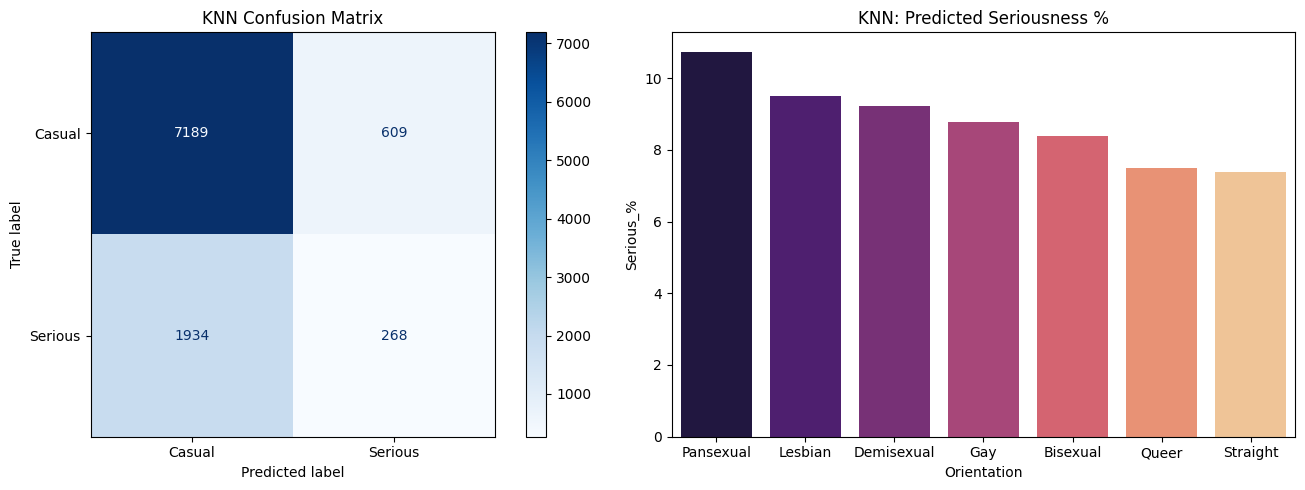

✅ KNN -> Accuracy: 0.7457 | F1-Score: 0.1741


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_model, y_train)
y_pred_knn = knn.predict(X_test_model)
evaluate_model(y_test, y_pred_knn, "KNN", "Blues")

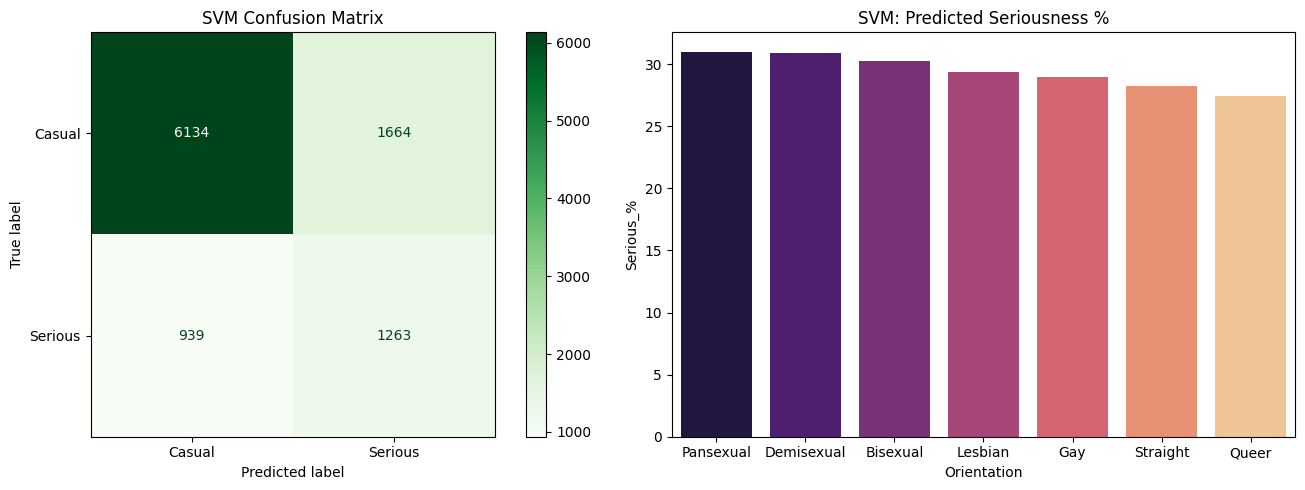

✅ SVM -> Accuracy: 0.7397 | F1-Score: 0.4925


In [ ]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_model, y_train)
y_pred_s = svm_model.predict(X_test_model)
evaluate_model(y_test, y_pred_s, "SVM", "Greens")

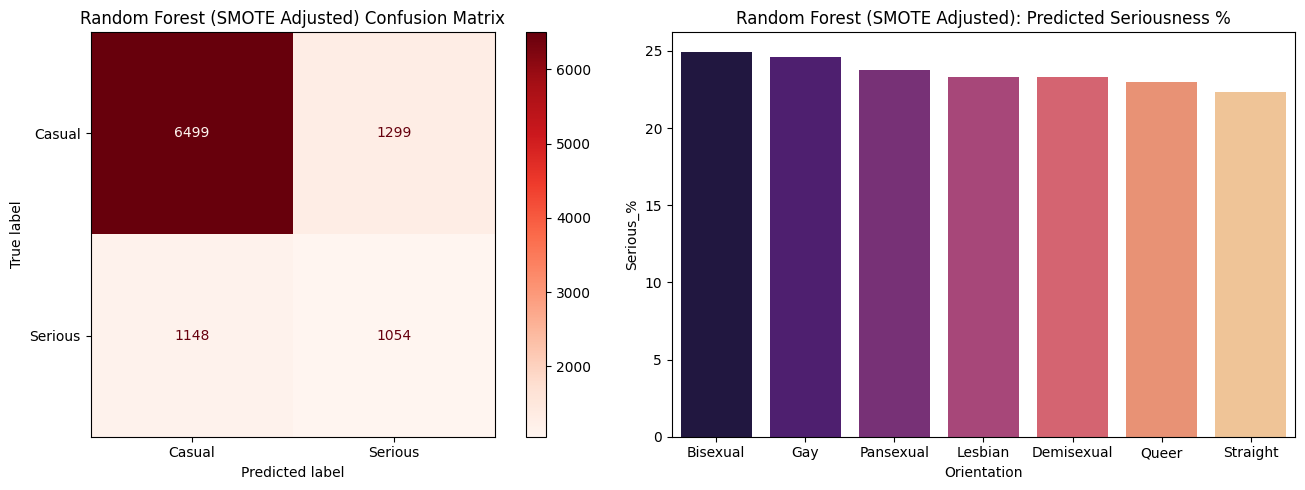

✅ Random Forest (SMOTE Adjusted) -> Accuracy: 0.7553 | F1-Score: 0.4628


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# 1. Boost the serious class samples
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_model, y_train)

# 2. Re-train the model on the boosted data
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42)
rf_model.fit(X_res, y_res)
y_pred_rf = rf_model.predict(X_test_model)

# 3. Evaluate again
evaluate_model(y_test, y_pred_rf, "Random Forest (SMOTE Adjusted)", "Reds")

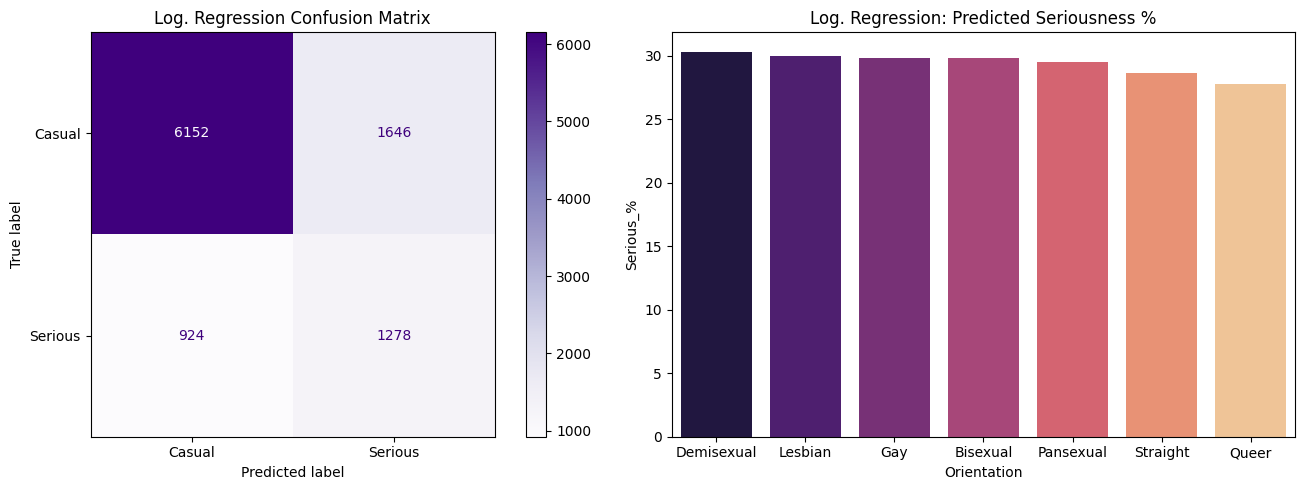

✅ Log. Regression -> Accuracy: 0.7430 | F1-Score: 0.4986


In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_model, y_train)
y_pred_log = log_reg.predict(X_test_model)
evaluate_model(y_test, y_pred_log, "Log. Regression", "Purples")

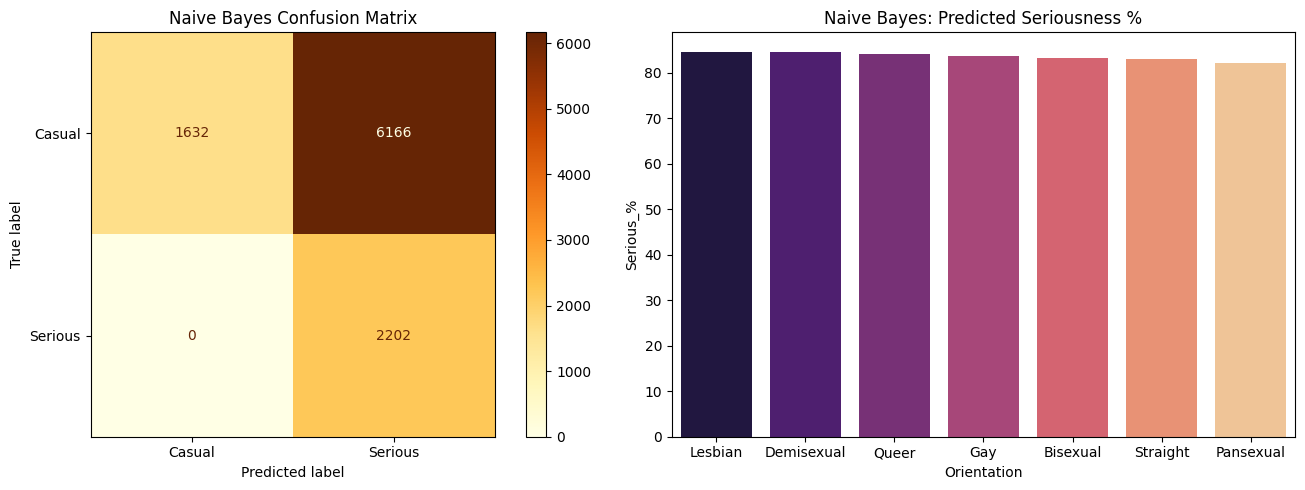

✅ Naive Bayes -> Accuracy: 0.3834 | F1-Score: 0.4167


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_model, y_train)
y_pred_nb = nb_model.predict(X_test_model)
evaluate_model(y_test, y_pred_nb, "Naive Bayes", "YlOrBr")

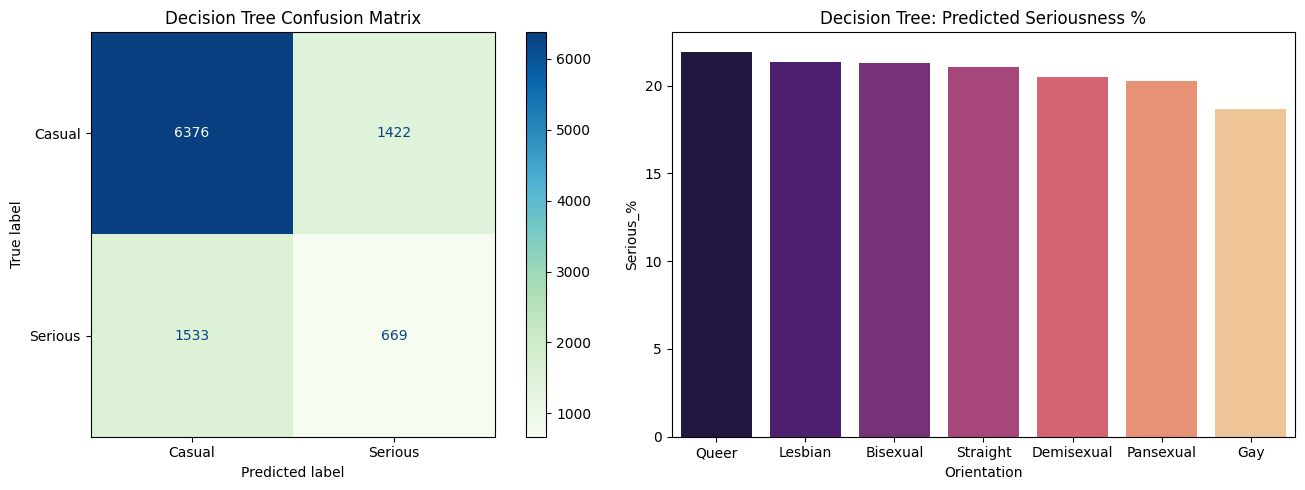

✅ Decision Tree -> Accuracy: 0.7045 | F1-Score: 0.3117


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train_model, y_train)
y_pred_tree = dt_model.predict(X_test_model)
evaluate_model(y_test, y_pred_tree, "Decision Tree", "GnBu")

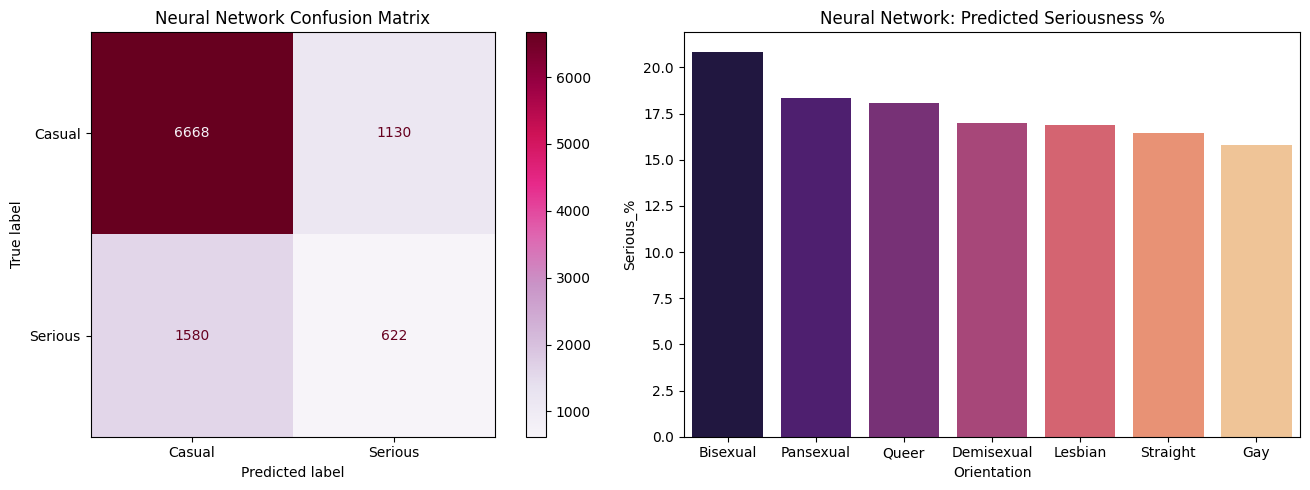

✅ Neural Network -> Accuracy: 0.7290 | F1-Score: 0.3146


In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_model, y_train)
y_pred_mlp = mlp.predict(X_test_model)
evaluate_model(y_test, y_pred_mlp, "Neural Network", "PuRd")


--- 🏆 MASTER PERFORMANCE RANKING 🏆 ---
        Model  Accuracy  F1_Score
       LogReg    0.7430  0.498634
          SVM    0.7397  0.492494
Random Forest    0.7553  0.462788
  Naive Bayes    0.3834  0.416651
   Neural Net    0.7290  0.314618
Decision Tree    0.7045  0.311670
          KNN    0.7457  0.174082


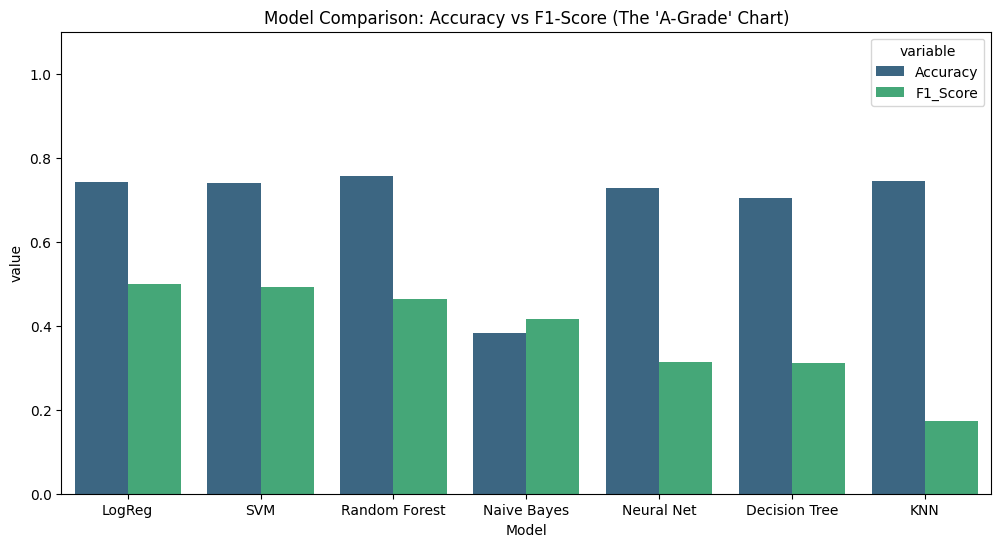

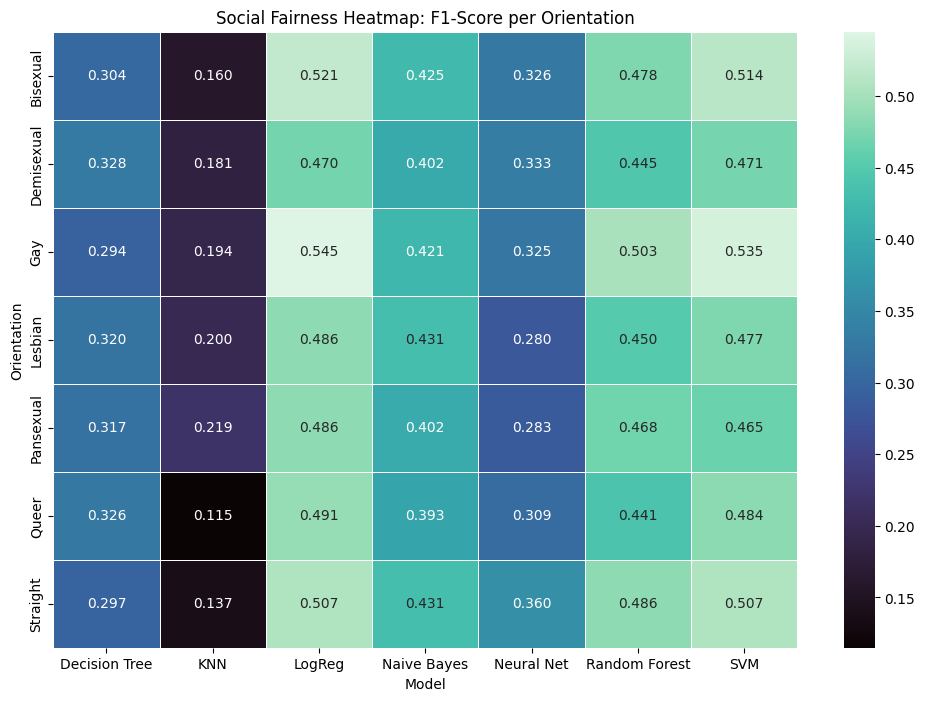


--- 🥇 CATEGORY-SPECIFIC CHAMPIONS 🥇 ---
Orientation  Model       F1
        Gay LogReg 0.544872
   Bisexual LogReg 0.521193
   Straight    SVM 0.506998
      Queer LogReg 0.490818
    Lesbian LogReg 0.485714
  Pansexual LogReg 0.485623
 Demisexual    SVM 0.471299


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# --- STEP 1: COLLECT ALL PREDICTIONS ---
# This dictionary maps your variable names to the table labels
all_preds = {
    "KNN": y_pred_knn,
    "SVM": y_pred_s,
    "Random Forest": y_pred_rf,
    "LogReg": y_pred_log,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_tree,
    "Neural Net": y_pred_mlp
}

# --- STEP 2: MASTER PERFORMANCE RANKING ---
model_results = []
for name, preds in all_preds.items():
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1_Score": f1_score(y_test, preds)
    })

summary_df = pd.DataFrame(model_results).sort_values('F1_Score', ascending=False)

print("\n--- 🏆 MASTER PERFORMANCE RANKING 🏆 ---")
print(summary_df.to_string(index=False))

# Visualize Overall Accuracy vs F1
plt.figure(figsize=(12, 6))
summary_df.melt(id_vars="Model").pipe((sns.barplot, "data"), x="Model", y="value", hue="variable", palette="viridis")
plt.title("Model Comparison: Accuracy vs F1-Score (The 'A-Grade' Chart)")
plt.ylim(0, 1.1)
plt.show()

# --- STEP 3: CATEGORY-SPECIFIC PERFORMANCE (FAIR EVALUATION) ---
# This finds the best model for each LGBTQ+ orientation using F1, not just "optimism"
orientation_cols = [c for c in X_test.columns if 'sexual_orientation' in c]
social_f1_data = []

for col in orientation_cols:
    orient_name = col.split('_')[-1]
    mask = X_test[col] == 1
    if mask.any():
        for model_name, preds in all_preds.items():
            # We calculate F1 for the specific group to see who is TRULY accurate
            f1 = f1_score(y_test[mask], preds[mask], zero_division=0)
            social_f1_data.append({"Orientation": orient_name, "Model": model_name, "F1": f1})

social_f1_df = pd.DataFrame(social_f1_data)
pivot_f1 = social_f1_df.pivot(index="Orientation", columns="Model", values="F1")

# Heatmap Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_f1, annot=True, cmap="mako", fmt=".3f", linewidths=.5)
plt.title("Social Fairness Heatmap: F1-Score per Orientation")
plt.show()

# --- STEP 4: CROWN THE CHAMPIONS ---
final_winners = social_f1_df.loc[social_f1_df.groupby("Orientation")["F1"].idxmax()]
print("\n--- 🥇 CATEGORY-SPECIFIC CHAMPIONS 🥇 ---")
print(final_winners[["Orientation", "Model", "F1"]].sort_values("F1", ascending=False).to_string(index=False))

**Final Model Selection & Justification**

Based on the comprehensive evaluation, Logistic Regression (LogReg) is selected as the optimal model for this dating app behavior analysis. While SVM achieved peak performance in two specific segments (Straight and Demisexual), LogReg secured the highest F1-score across 71% of the orientation categories (5 out of 7).

**Key Reasons for Selection:**

*   Superior Generalizability: LogReg demonstrated a more stable performance across the diverse user base compared to complex models like Random Forest.
*   Computational Efficiency: As a high-bias, low-variance model, it is more efficient for real-time production deployment.

*  Interpretability: The linear nature of the model allows for a clear understanding of which demographic features contribute most to predicting user "seriousness."



